# **Implementing PCA in Python with scikit-learn**

**Principal Component Analysis (PCA)** is a **dimensionality reduction** technique. It transform high-dimensional data into a smaller number of dimensions called **principal components** and keeps important information in the data. In this article, we will learn about how we implement PCA in Python using scikit-learn. Here are the steps:

### **Step 1: Import necessary libraries**
We import all the libraries needed like numpy , pandas, matplotlib, seaborn and scikit learn.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

### **Step 2: Load the Data**
We will use breast cancer dataset. This dataset has 569 data items with 30 input attributes. There are two output classes-benign and malignant. This reads the dataset file and displays the first 5 rows. You can download the dataset from here.

In [16]:
df = pd.read_csv('../Imports/PCAsample.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### **Step 3: Data Cleaning and Preprocessing**

It drops unnecessary columns like id, Unnamed: 32 and converts diagnosis column: Malignant to 1 and Benign to 0.

In [17]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

### **Step 4: Separate Features and Target**
In this separate features X contains input features (30 columns) and y contains the target labels (0 or 1)

In [18]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

### **Step 5: Standardize the Data**
StandardScaler transforms features so they all have a mean = 0 and standard deviation = 1 which helps PCA to treat all features equally.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:2])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]]


### **Step 6: Apply PCA Algorithm**
It reduces the data to 2 principal components. PCA finds combinations of original features that explain the most variation in the data.

We reduce 30 features to 2 components. Each row now has 2 values (PC1, PC2) instead of 30. These components contain the most variation from original data.

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:2])

[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]]


### **Step 7: Explained Variance**
It tells how much information each principal component holds.

PC1 explains 44% of data and PC2 explains 19%. Combined these 2 components explain 63% of all data variation.

In [21]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.44272026 0.18971182]
Cumulative: [0.44272026 0.63243208]


### **Step 8: Visualization Before vs After PCA**
First plot shows original scaled data using first 2 features and second plot shows reduced data using PCA's 2 components. Colors represent diagnosis Benign or Malignant.

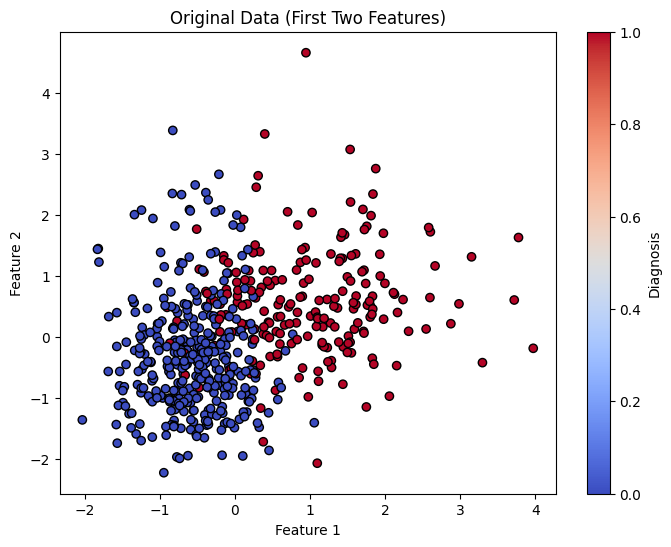

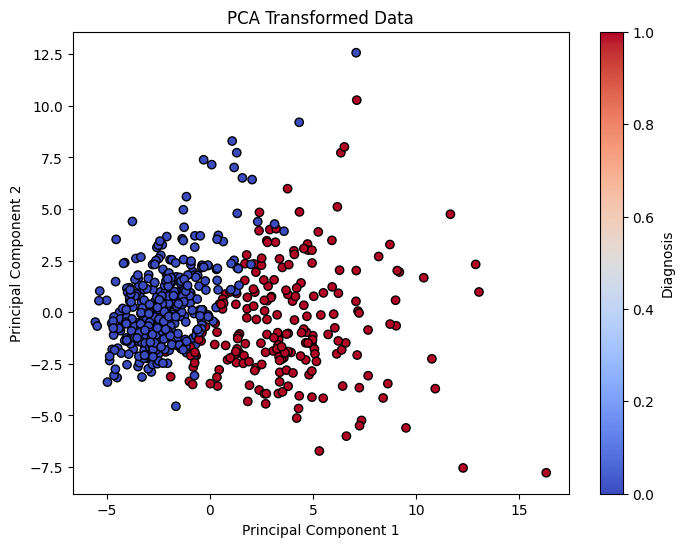

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data (First Two Features)")
plt.colorbar(label="Diagnosis")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Diagnosis")
plt.show()

### **Step 9: Train a Model on PCA Data**

It splits PCA data into training and test sets. Train a Logistic Regression model to classify tumors and predicts and evaluate the model.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



### **Step 10: Confusion Matrix**

It shows how many predictions were correct or incorrect and helps to visualize true vs. false predictions.

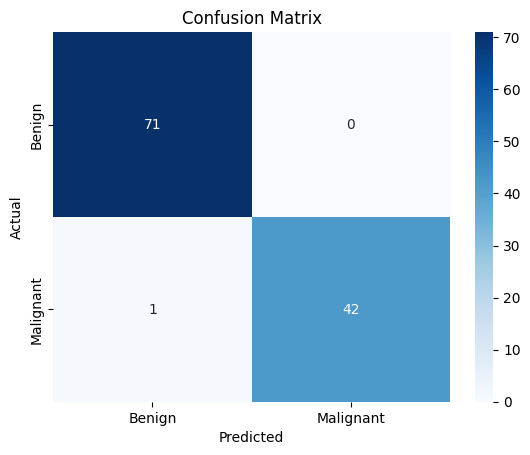

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **Step 11: Reconstruct Data and Check Information Loss**

PCA reduces data size but some information is lost. This step converts reduced data back to its original shape and measures how much data was lost in the reduction process.

In [25]:
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_loss = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Reconstruction Loss: {reconstruction_loss:.4f}")

Reconstruction Loss: 0.3676
